In [1]:
import xarray as xr

In [3]:
clouds = xr.open_dataset('../data/ice_flc_percent_2008_2020_2deg.nc')

In [4]:
clouds

<xarray.Dataset> Size: 10MB
Dimensions:          (year: 13, month: 12, latitude: 90, longitude: 180)
Coordinates:
  * year             (year) int16 26B 2008 2009 2010 2011 ... 2018 2019 2020
  * month            (month) int8 12B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude         (latitude) float32 360B -89.0 -87.0 -85.0 ... 87.0 89.0
  * longitude        (longitude) float32 720B -179.0 -177.0 ... 177.0 179.0
Data variables:
    ice_flc_percent  (year, month, latitude, longitude) float32 10MB ...
    yyyymm           (year, month) int32 624B ...
Attributes:
    title:                      Monthly ice floe concentration percentage on ...
    summary:                    Dataset containing monthly ice floe concentra...
    time_coverage_start:        2008-01
    time_coverage_end:          2020-12
    geospatial_lat_min:         -89.0
    geospatial_lat_max:         89.0
    geospatial_lon_min:         -179.0
    geospatial_lon_max:         179.0
    geospatial_lat_resolution:  2 degrees
    geospatial_lon_resolution:  2 degrees
    coordinate_mapping:         Original coordinates were remapped to the nea...
    Conventions:                CF-1.8

In [5]:
# compute monhtly means and stack them
lst_2008 = xr.open_mfdataset('/mnt/data7/nfs4/avh_lst/sdupuis/EUSTACE/All_Arctic/2008/AVMEA/LST_AVMEA_All_Arctic__v.11.0__*DAY.nc', engine='netcdf4')

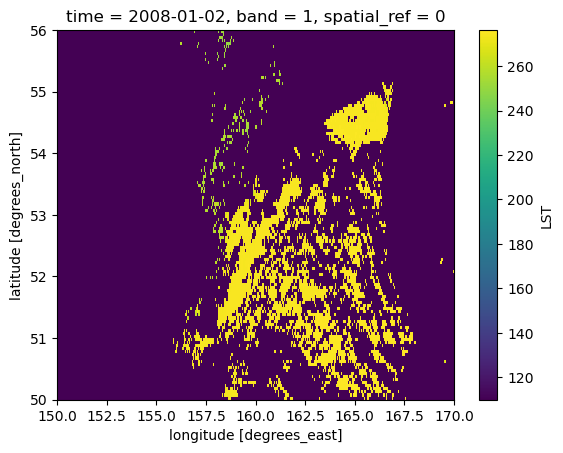

In [15]:
lst_2008['LST'].isel(time=1).sel(lat=slice(50,56), lon=slice(150,170)).plot();

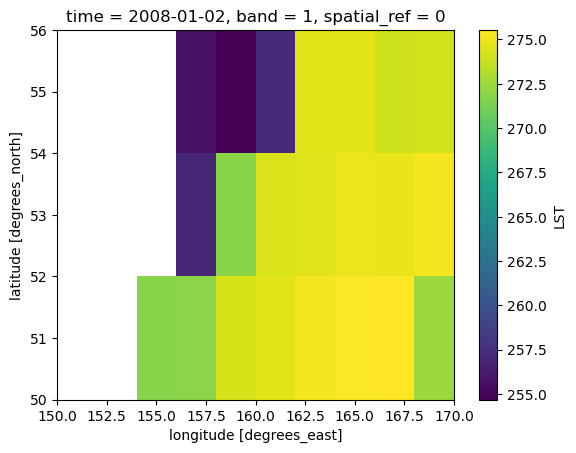

In [20]:
ds_coarse['LST'].isel(time=1).sel(lat=slice(50,55), lon=slice(150,170)).plot();

In [17]:
# remove clouds first
lst_2008 = lst_2008.where(lst_2008['LST']>110)

In [18]:
lst_2008

<xarray.Dataset> Size: 101GB
Dimensions:      (lat: 800, lon: 7200, time: 366)
Coordinates:
  * lat          (lat) float32 3kB 50.03 50.08 50.12 50.17 ... 89.88 89.93 89.97
  * lon          (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time         (time) datetime64[ns] 3kB 2008-01-01 2008-01-02 ... 2008-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon, time) float64 17GB dask.array<chunksize=(800, 7200, 1), meta=np.ndarray>
    satzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    sunzen       (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    scan_time    (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    test_mae     (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>
    r2           (time, lat, lon) float64 17GB dask.array<chunksize=(1, 800, 7200), meta=np.ndarray>

In [19]:
ds_coarse = lst_2008.coarsen(lat=40, lon=40, boundary="trim").mean()

In [9]:
ds_coarse

<xarray.Dataset> Size: 63MB
Dimensions:      (lat: 20, lon: 180, time: 366)
Coordinates:
  * lat          (lat) float32 80B 51.0 53.0 55.0 57.0 ... 83.0 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 3kB 2008-01-01 2008-01-02 ... 2008-12-31
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon, time) float64 11MB dask.array<chunksize=(20, 180, 1), meta=np.ndarray>
    satzen       (time, lat, lon) float64 11MB dask.array<chunksize=(1, 20, 180), meta=np.ndarray>
    sunzen       (time, lat, lon) float64 11MB dask.array<chunksize=(1, 20, 180), meta=np.ndarray>
    scan_time    (time, lat, lon) float64 11MB dask.array<chunksize=(1, 20, 180), meta=np.ndarray>
    test_mae     (time, lat, lon) float64 11MB dask.array<chunksize=(1, 20, 180), meta=np.ndarray>
    r2           (time, lat, lon) float64 11MB dask.array<chunksize=(1, 20, 180), meta=np.ndarray>

In [ ]:
ds_coarse = ds_coarse.assign_coords(lat=target.lat, lon=target.lon)

In [ ]:
lst_2008